In [1]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from VAE.architecture import VAE, Encoder, Decoder
from VAE.loss import PerceptualLoss
from VAE.VAE_trainer import VAE_trainer
import os
from sklearn.manifold import TSNE
import wandb
from tqdm import tqdm

In [ ]:
# class Derma64Dataset(Dataset):
#     def __init__(self, images_path, labels_path=None, transform=None):
#         self.images = np.load(images_path)       # shape: [N, 64, 64, 3]
#         self.labels = np.load(labels_path) if labels_path else None
#         self.transform = transform

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img = self.images[idx].astype(np.float32) / 255.0  # normalize to 0–1
#         img = torch.from_numpy(img).permute(2,0,1)         # HWC -> CHW
#         if self.transform:
#             img = self.transform(img)
#         if self.labels is not None:
#             label = int(self.labels[idx])
#             return img, label
#         return img

In [2]:

class Derma64Dataset(Dataset):
    def __init__(self, images_path, labels_path=None, augment=False):
        self.images  = np.load(images_path)          # [N, 64, 64, 3]
        self.labels  = np.load(labels_path) if labels_path else None
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1)   # HWC → CHW

        if self.augment:
            # Simple augmentations without torchvision dependency
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])          # horizontal flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])          # vertical flip

        if self.labels is not None:
            return img, int(self.labels[idx].item())
        return img

In [4]:
BATCH_SIZE = 256

train_dataset = Derma64Dataset("data/train_images.npy", "data/train_labels.npy")
print(len(train_dataset))
val_dataset = Derma64Dataset("data/val_images.npy", "data/val_labels.npy")
test_dataset = Derma64Dataset("data/test_images.npy", "data/test_labels.npy")
print(len(val_dataset))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

7007
1003


We have 7 clases

In [4]:
np.unique(val_dataset.labels)
sum(val_dataset.labels==0)


array([33])

My attempts at doing VAE with simple conv layers failed regardless of hyperparams like epoch num, stride, padding, layers, latent_dim, and etc.

The failure was that the reconstructed images were basically blurred, averaged with no real feature remaining.



Here, I will attempt to add resnet layers with more batch normalization.

Resnet layers with laten_dim = 64 did not produce great result (60 epochs). I increased the laten_dim to 256, 512 and the results were better. Gradient kept getting unstable so I used a gradient clipper. Also, since KL was getting too small in the begining and did not allow the mse to grow smaller afterwards, I made the beta variable (beta * kl in loss) to start very small and slowly grow bigger. The results are not terrible and I believe the actual good results could be achieved with epoch around 100 for latent_dim = 512. But for now, I will keep working on my makinga a Tutor based on the latent_dim = 256 and epoch 100, if it's not good enough, I will change to 512 dimension

256 was decent... will continue with that

In [5]:
from VAE.architecture import Encoder, Decoder, VAE

LATENT_DIM = 512
EPOCHS = 100
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_SHAPE = (3, 64, 64)

encoder_layer_list = [
    (1, 32),
    (1, 64),
    (1, 128),
]

decoder_layer_list = [
    (1, 128),
    (1, 64),
    (1, 32),
]


run the following cell if you want to load a saved model, otherwise skip

In [6]:
def load_model(model, path):
    state_dict = torch.load(os.path.join(path, "VAE_model.pt"))
    model.load_state_dict(state_dict, strict=False)
    model.basis = torch.load(os.path.join(path, "vae_basis.pt"))
    return model

encoder1 = Encoder(latent_dim=LATENT_DIM, layer_list=encoder_layer_list)
decoder1 = Decoder(target_shape=TARGET_SHAPE, latend_dim=LATENT_DIM, layer_list=decoder_layer_list)
vae = VAE(encoder=encoder1, decoder=decoder1, laten_dim=LATENT_DIM, input_dim=TARGET_SHAPE,).to(DEVICE)

vae = load_model(vae, "val_model")

Run the following cell if you want to train the vae. otherwise, skip

In [ ]:
vae, train_losses, val_losses = VAE_trainer(LATENT_DIM,
                                                  encoder_layer_list,
                                                  decoder_layer_list,
                                                  TARGET_SHAPE,
                                                  train_loader=train_loader,
                                                  val_loader=val_loader,
                                                  DEVICE=DEVICE,
                                                  epochs=EPOCHS,
                                                  lr=LR,
                                                  SAVE=False)
# --- Plot ---
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_curve.png")
plt.show()

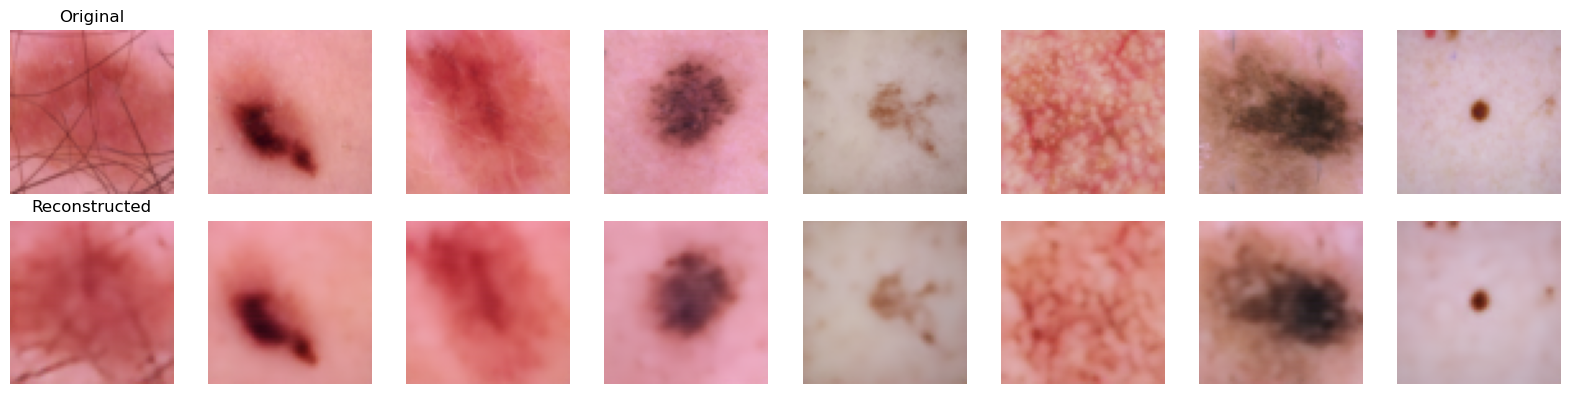

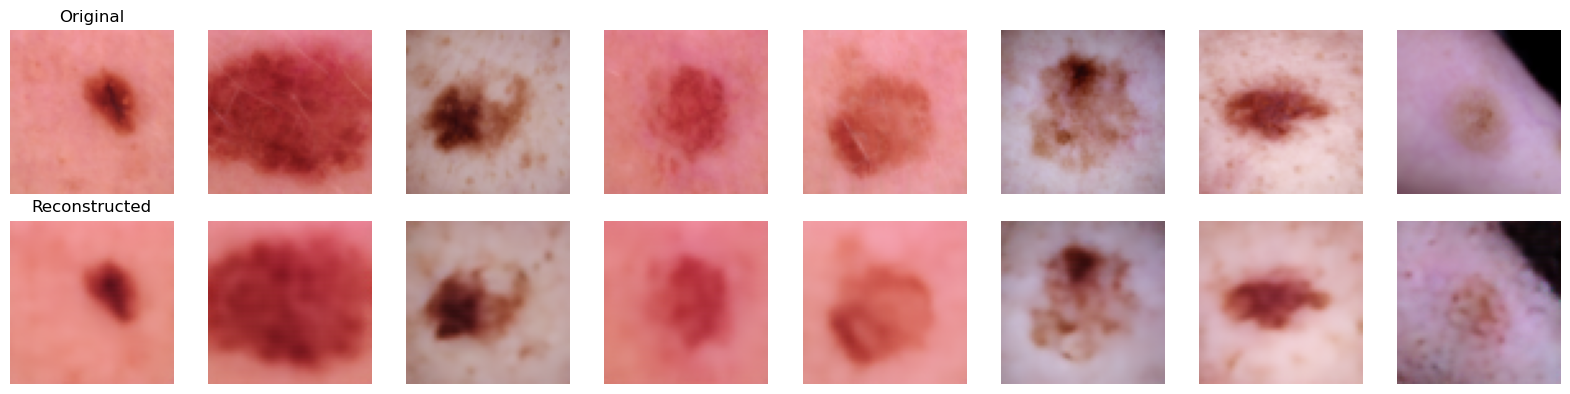

In [ ]:
def visualize_reconstructions(model, loader, device, n=8):
    model.eval()
    batch = next(iter(loader))
    imgs = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
    imgs = imgs[:n]

    with torch.no_grad():
        x_recon, _, _ ,_,_= model(imgs)

    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        # Original
        axes[0, i].imshow(imgs[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original")

        # Reconstructed
        axes[1, i].imshow(x_recon[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed")

    plt.tight_layout()
    plt.savefig("reconstructions1.png")
    plt.show()

# Call after training:
visualize_reconstructions(vae, train_loader, DEVICE)
visualize_reconstructions(vae, val_loader, DEVICE)

In [8]:
def sample_new_lesions(model, n=16):
    model.eval()
    with torch.no_grad():
        # Sample from standard normal latent space
        z = torch.randn(n, model.latent_dim).to(next(model.parameters()).device)
        samples = model.decoder(z).cpu()  # shape: [n, 3, 64, 64]

    # Plot
    import torchvision
    grid = torchvision.utils.make_grid(samples, nrow=4)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Synthetic Lesions")
    plt.show()

In [9]:
def interpolate_lesions(model, loader, idx1=0, idx2=1, steps=8):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        img1, img2 = images[idx1].unsqueeze(0), images[idx2].unsqueeze(0)
        
        # Encode to latent space
        z_mean, z_log_var = model.encoder(img1)
        z1 = torch.distributions.Normal(z_mean, torch.exp(0.5 * z_log_var) + 1e-6).rsample()
        z_mean2, z_log_var2 = model.encoder(img2)
        z2 = torch.distributions.Normal(z_mean2, torch.exp(0.5 * z_log_var2) + 1e-6).rsample()
        
        # Linear interpolation
        interpolated = []
        for alpha in torch.linspace(0,1,steps):
            z = (1-alpha)*z1 + alpha*z2
            recon = model.decoder(z)
            interpolated.append(recon.cpu())
        
        interpolated = torch.cat(interpolated, dim=0)
    
    # Plot
    import torchvision
    grid = torchvision.utils.make_grid(interpolated, nrow=steps)
    plt.figure(figsize=(steps,2))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.title("Latent Interpolation")
    plt.show()

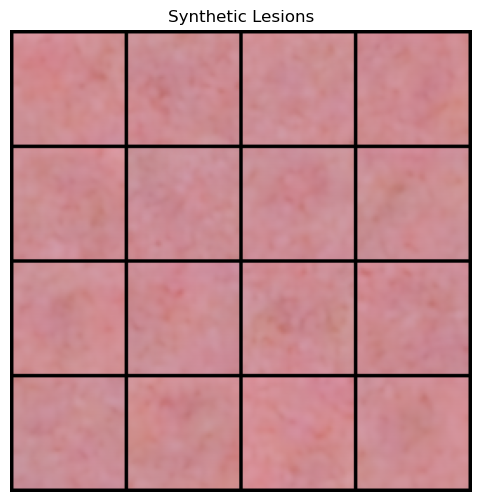

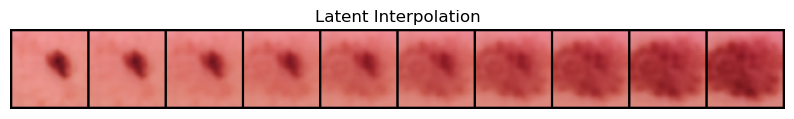

In [10]:
# Sample 4 random lesions
sample_new_lesions(vae, n=16)

# Interpolate between first two images in validation set
interpolate_lesions(vae, val_loader, idx1=0, idx2=1, steps=10)

Now let's train a classifier that classifies the lesions

In [11]:
from derma_cnn import DermaCNN, train_one_epoch, evaluate

In [12]:
BATCH_SIZE   = 128
EPOCHS       = 20
LR           = 1e-3
NUM_CLASSES  = 7
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
print(f"Device: {DEVICE}")
# Datasets & loaders
# train_ds = Derma64Dataset("data/train_images.npy", "data/train_labels.npy", augment=True)
# val_ds   = Derma64Dataset("data/val_images.npy",   "data/val_labels.npy")
# test_ds  = Derma64Dataset("data/test_images.npy",  "data/test_labels.npy")

# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
# test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


If you want to use already trained model, run the following cell, otherwise, skip

In [13]:
classifier = DermaCNN(num_classes=NUM_CLASSES).to(DEVICE)
classifier.load_state_dict(torch.load("best_derma_cnn.pt", map_location=DEVICE))

<All keys matched successfully>

If you want to train the classifier from the beginning, start here

In [ ]:


# Model

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"\nModel parameters: {sum(p.numel() for p in classifier.parameters()):,}\n")

# Training loop
best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(classifier, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(classifier, val_loader, criterion, DEVICE)
    scheduler.step()

    marker = " ← best" if val_acc > best_val_acc else ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(classifier.state_dict(), "best_derma_cnn.pt")

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"train_loss={train_loss:.4f}  train_acc={train_acc:.3f}  "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.3f}{marker}"
    )

# Final test evaluation
print("\nLoading best model for test evaluation...")

test_loss, test_acc = evaluate(classifier, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.3f}")




  [!] Only 0 correct samples found for 'Dermatofibroma'
Saved → results_grid.png


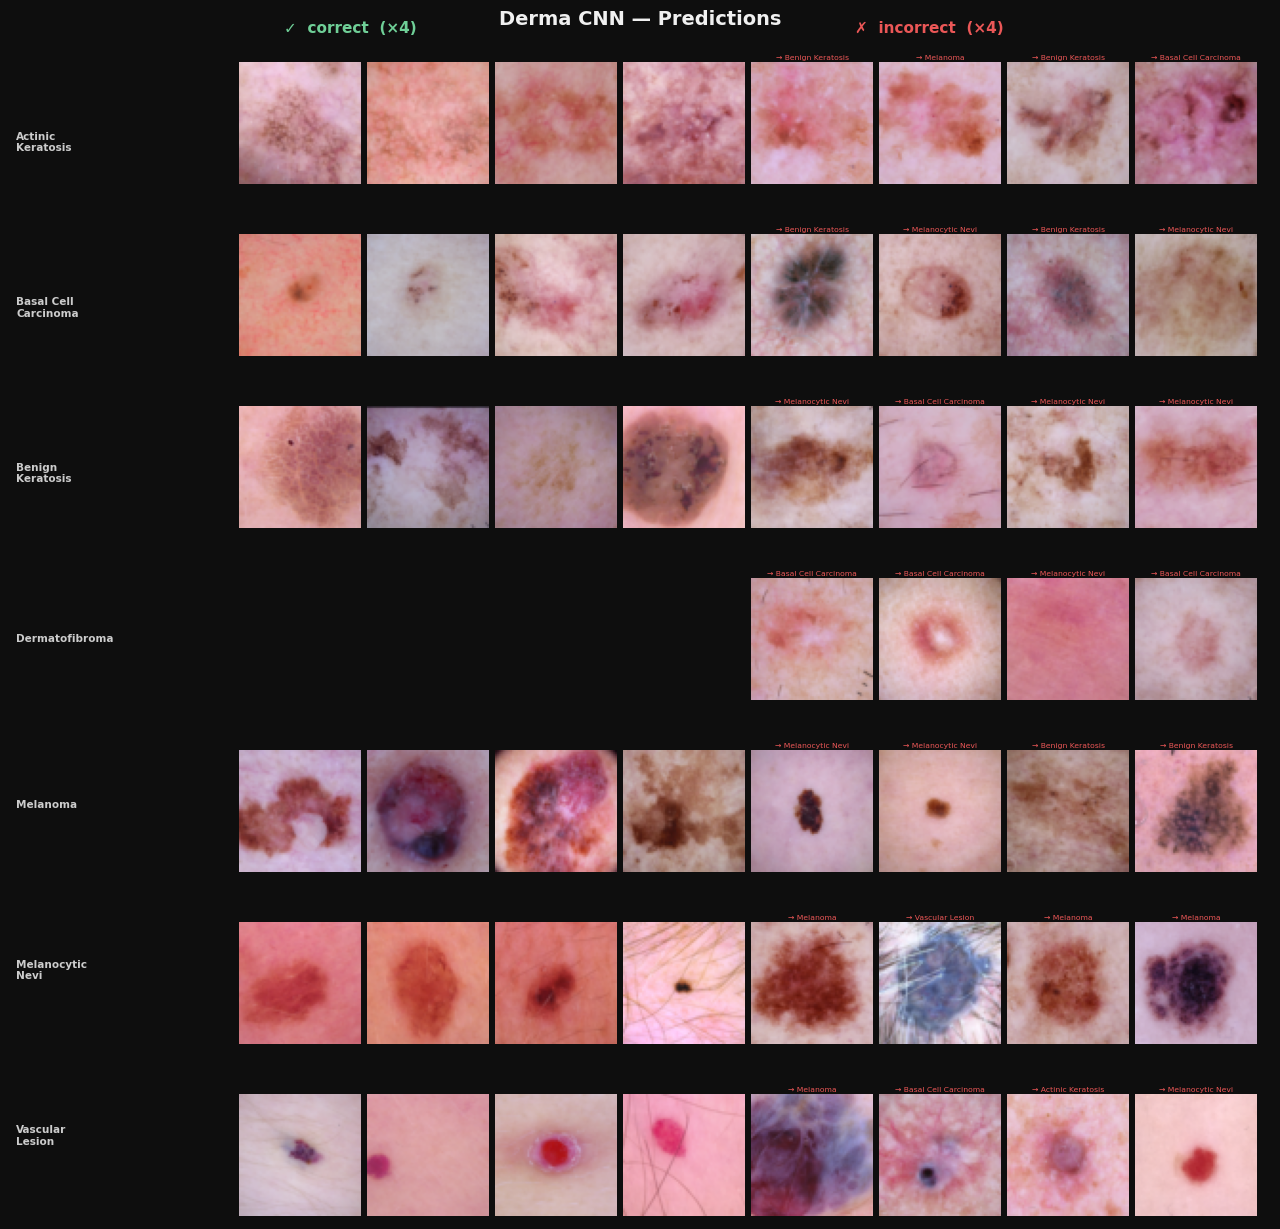

In [14]:


# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from derma_cnn import DermaCNN, Derma64Dataset
# from torch.utils.data import DataLoader

# ── HAM10000 class names (adjust if your labels differ) ──────────────────────
CLASS_NAMES = {
    0: "Actinic\nKeratosis",
    1: "Basal Cell\nCarcinoma",
    2: "Benign\nKeratosis",
    3: "Dermatofibroma",
    4: "Melanoma",
    5: "Melanocytic\nNevi",
    6: "Vascular\nLesion",
}
SAMPLES_PER_CLASS = 4   # how many correct + incorrect examples to show per row

# ─────────────────────────────────────────────────────────────────────────────

def collect_samples(model, dataset, n=SAMPLES_PER_CLASS):
    """Return dicts mapping class → list of (img_np, pred) for correct/wrong."""
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    correct = {c: [] for c in range(NUM_CLASSES)}
    wrong   = {c: [] for c in range(NUM_CLASSES)}

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            for img, true, pred in zip(imgs, labels, preds):
                true, pred = true.item(), pred.item()
                img_np = img.permute(1, 2, 0).numpy()   # CHW → HWC
                if true == pred and len(correct[true]) < n:
                    correct[true].append((img_np, pred))
                elif true != pred and len(wrong[true]) < n:
                    wrong[true].append((img_np, pred))
            if all(len(correct[c]) == n and len(wrong[c]) == n
                   for c in range(NUM_CLASSES)):
                break

    return correct, wrong


def plot_grid(correct, wrong):
    n      = SAMPLES_PER_CLASS
    nclass = NUM_CLASSES
    cols   = n * 2 + 1          # correct cols | spacer | wrong cols
    rows   = nclass

    fig = plt.figure(figsize=(cols * 1.4, rows * 1.6 + 1.2), facecolor="#0e0e0e")
    fig.suptitle("Derma CNN — Predictions", color="#f0f0f0",
                 fontsize=14, fontweight="bold", y=0.995)

    # Column headers
    header_ax = fig.add_axes([0, 0.965, 1, 0.03])
    header_ax.axis("off")
    header_ax.text(0.27, 0.5, f"✓  correct  (×{n})",
                   ha="center", va="center", color="#6fcf97",
                   fontsize=11, fontweight="bold")
    header_ax.text(0.73, 0.5, f"✗  incorrect  (×{n})",
                   ha="center", va="center", color="#eb5757",
                   fontsize=11, fontweight="bold")

    gs = fig.add_gridspec(rows, cols,
                          left=0.08, right=0.99,
                          top=0.955, bottom=0.02,
                          wspace=0.05, hspace=0.35)

    for row, cls in enumerate(range(nclass)):
        # Class label on the left
        label_ax = fig.add_subplot(gs[row, 0])
        label_ax.axis("off")
        # invisible — we use fig.text for precise placement
        y_pos = 1 - (row + 0.5) / rows
        fig.text(0.005, 0.02 + (rows - row - 0.5) / rows * 0.935,
                 CLASS_NAMES.get(cls, f"Class {cls}"),
                 ha="left", va="center", color="#cccccc",
                 fontsize=7.5, fontweight="bold")

        # Correct samples (cols 1..n)
        for i, (img, pred) in enumerate(correct[cls][:n]):
            ax = fig.add_subplot(gs[row, i + 1])
            ax.imshow(np.clip(img, 0, 1))
            ax.axis("off")
            for spine in ax.spines.values():
                spine.set_edgecolor("#6fcf97")
                spine.set_linewidth(1.5)
                spine.set_visible(True)

        # Incorrect samples (cols n+1..2n, skip middle spacer col)
        for i, (img, pred) in enumerate(wrong[cls][:n]):
            ax = fig.add_subplot(gs[row, i + n + 1])
            ax.imshow(np.clip(img, 0, 1))
            ax.axis("off")
            pred_name = CLASS_NAMES.get(pred, str(pred)).replace("\n", " ")
            ax.set_title(f"→ {pred_name}", fontsize=5.5,
                         color="#eb5757", pad=2)
            for spine in ax.spines.values():
                spine.set_edgecolor("#eb5757")
                spine.set_linewidth(1.5)
                spine.set_visible(True)

    plt.savefig("results_grid.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("Saved → results_grid.png")
    plt.show()



# model = DermaCNN(num_classes=NUM_CLASSES).to(DEVICE)
# model.load_state_dict(torch.load("best_derma_cnn.pt", map_location=DEVICE))
# print("Model loaded.")

# Load val set (or swap for test_images/test_labels)
# dataset = Derma64Dataset("data/val_images.npy", "data/val_labels.npy")
# print(f"Dataset size: {len(dataset)}")

correct, wrong = collect_samples(classifier, val_dataset)

# Warn if not enough samples found for some class
for c in range(NUM_CLASSES):
    name = CLASS_NAMES.get(c, str(c)).replace("\n", " ")
    if len(correct[c]) < SAMPLES_PER_CLASS:
        print(f"  [!] Only {len(correct[c])} correct samples found for '{name}'")
    if len(wrong[c]) < SAMPLES_PER_CLASS:
        print(f"  [!] Only {len(wrong[c])} incorrect samples found for '{name}'")

plot_grid(correct, wrong)




In [25]:

class LatentTransformer(nn.Module):
    def __init__(self, latent_dim=256):
        super(LatentTransformer, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Linear(1024, 2048),
            nn.LayerNorm(2048),
            nn.GELU(),
            nn.Linear(2048, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Linear(1024, latent_dim)
        )
        
        
        self.scale = nn.Parameter(torch.ones(1) * 2.0)
    
    def forward(self, x):
        return torch.tanh(self.net(x)) * self.scale


class VAEClassifierPipeline(nn.Module):
    def __init__(self, vae, transformer, classifier, alpha=0.5):
        super(VAEClassifierPipeline, self).__init__()
        self.vae = vae
        self.transformer = transformer
        self.classifier = classifier
        
        for param in self.vae.parameters():
            param.requires_grad = False
        
        for param in self.classifier.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        mu, log_var = self.vae.encoder(x)

        original_mu = mu.detach()
        original_log_var = log_var.detach()
        
        # Transformer outputs a delta (epsilon), not a full new mu
        epsilon = self.transformer(original_mu)
        transformed_mu = original_mu + epsilon
        
        decoded = self.vae.decoder(transformed_mu)
        logits = self.classifier(decoded)

        return {
            'logits': logits,
            'decoded_image': decoded,
            'original_mu': original_mu,
            'original_log_var': original_log_var,
            'transformed_mu': transformed_mu,
            'epsilon': epsilon  # exposed for logging/regularization
        }


def compute_kl_divergence(epsilon, original_log_var):
    denom = torch.exp(original_log_var).clamp(min=1e-3)
    kl_div = 0.5 * torch.sum(epsilon.pow(2) / denom)
    return kl_div


In [21]:
# latent_transformer = LatentTransformer(latent_dim=LATENT_DIM).to(DEVICE)
# # latent_transformer.load_state_dict(torch.load('models/mu_transformer.pth'))
# pipeline = VAEClassifierPipeline(vae, latent_transformer, classifier).to(DEVICE)

In [26]:
# Freeze VAE and put in eval mode (stabilizes BatchNorm/Dropout, doesn't affect grad flow)
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

# Hyperparameters for the loss regularization
mse_weight = 0.5
kl_weight = 0.000005
latent_transformer = LatentTransformer(latent_dim=LATENT_DIM).to(DEVICE)
pipeline = VAEClassifierPipeline(vae, latent_transformer, classifier).to(DEVICE)

optimizer = optim.Adam(pipeline.transformer.parameters(), lr=1e-3)
classification_criterion = nn.CrossEntropyLoss(reduction='mean')

# Training loop for the latent transformer
print("Training the latent space transformer...")
num_epochs = 20
for epoch in range(num_epochs):
    pipeline.transformer.train()
    pipeline.vae.eval()       # keep vae in eval mode throughout
    pipeline.classifier.eval() # keep classifier in eval mode throughout
    running_loss = 0.0
    running_class_loss = 0.0
    running_mse_loss = 0.0
    running_kl_loss = 0.0
    changing_kl_rate = min(0.00005, kl_weight * epoch / 10)
    print(changing_kl_rate)
    for images, labels in tqdm(train_loader, desc=f"Transformer Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        outputs = pipeline(images)
        
        class_loss = classification_criterion(outputs['logits'], labels)
        mse_loss = F.mse_loss(outputs['decoded_image'], images, reduction='mean')
        kl_loss = compute_kl_divergence(outputs['epsilon'], outputs['original_log_var'])
        
        total_loss = 10000.0 * class_loss + mse_weight * mse_loss + changing_kl_rate * kl_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(pipeline.transformer.parameters(), max_norm=3.0)
        optimizer.step()
        
        running_loss += total_loss.item()
        running_class_loss += class_loss.item()
        running_mse_loss += mse_loss.item()
        running_kl_loss += kl_loss.item()
    
    avg_loss = running_loss / len(train_loader)
    avg_class_loss = running_class_loss / len(train_loader)
    avg_mse_loss = running_mse_loss / len(train_loader)
    avg_kl_loss = running_kl_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Total Loss: {avg_loss:.4f}, '
          f'Class Loss: {avg_class_loss:.4f}, '
          f'MSE Loss: {avg_mse_loss:.4f}, '
          f'KL Loss: {avg_kl_loss:.4f}')

# Evaluation
pipeline.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = pipeline(images)
        _, predicted = torch.max(outputs['logits'].data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy with Latent Transformation: {100 * correct / total:.2f}%')

# Evaluate original classifier on unmodified images
classifier.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating Original Classifier"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = classifier(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Original Classifier Accuracy: {100 * correct / total:.2f}%')

# torch.save(latent_transformer.state_dict(), 'val_mode/mu_transformer_change_nograd.pth')

Training the latent space transformer...
0.0


Transformer Epoch 1/20:   0%|          | 0/55 [00:00<?, ?it/s]

Transformer Epoch 1/20: 100%|██████████| 55/55 [01:52<00:00,  2.04s/it]


Epoch [1/20], Total Loss: 6248.6881, Class Loss: 0.6249, MSE Loss: 0.0011, KL Loss: 35020274.5909
5.000000000000001e-07


Transformer Epoch 2/20: 100%|██████████| 55/55 [01:55<00:00,  2.10s/it]


...

Epoch [20/20], Total Loss: 1562.6776, Class Loss: 0.1246, MSE Loss: 0.0016, KL Loss: 33325883.5636


Evaluating: 100%|██████████| 16/16 [00:13<00:00,  1.15it/s]


Test Accuracy with Latent Transformation: 75.41%


Evaluating Original Classifier: 100%|██████████| 16/16 [00:04<00:00,  3.70it/s]

Original Classifier Accuracy: 77.71%


In [23]:

def accuracy(model, loader, use_pipeline=False):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if use_pipeline:
                logits = model(images)['logits']
            else:
                logits = model(images)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return 100 * correct / total

results = {}
for split, loader in [('Train', train_loader), ('Val', val_loader), ('Test', test_loader)]:
    results[f'{split} (classifier only)'] = accuracy(classifier, loader, use_pipeline=False)
    results[f'{split} (pipeline)']        = accuracy(pipeline,   loader, use_pipeline=True)

print("\n── Results ──────────────────────────────────────")
for name, acc in results.items():
    print(f"  {name:<30} {acc:.2f}%")

KeyboardInterrupt: 

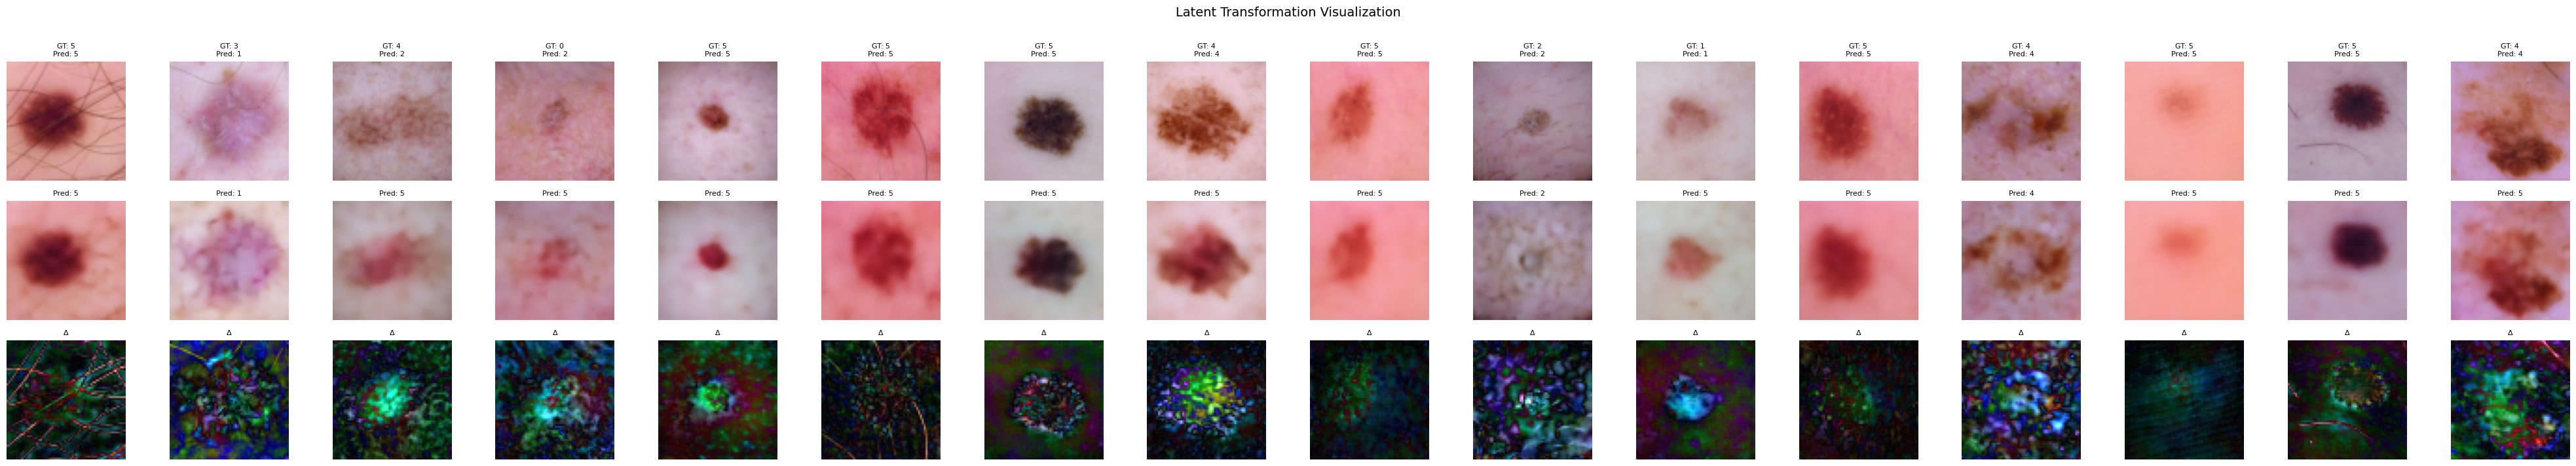

In [28]:
import matplotlib.pyplot as plt
import torch

CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]  # replace with actual class names if available

def visualize_transformations(pipeline, dataset, device, n=8):
    pipeline.eval()
    
    # Grab a fixed batch
    images, labels = zip(*[dataset[i] for i in range(n)])
    images = torch.stack(images).to(device)
    labels = torch.tensor(labels).to(device)

    with torch.no_grad():
        outputs = pipeline(images)
        original_preds = torch.argmax(classifier(images), dim=1)
        transformed_preds = torch.argmax(outputs['logits'], dim=1)
        decoded = outputs['decoded_image']

    # Denormalize if needed — adjust mean/std to match your dataset
    def to_img(t):
        t = t.cpu().clamp(0, 1)
        return t.permute(1, 2, 0).numpy() if t.shape[0] == 3 else t.squeeze(0).numpy()

    fig, axes = plt.subplots(3, n, figsize=(n * 2.5, 7))
    fig.suptitle("Latent Transformation Visualization", fontsize=14, y=1.01)

    row_labels = ["Original", "Reconstructed\n(transformed μ)", "Diff (×5)"]
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=10)

    for i in range(n):
        orig = to_img(images[i])
        rec = to_img(decoded[i])
        diff = to_img((decoded[i] - images[i]).abs() * 5)

        true_label = CLASS_NAMES[labels[i].item()]
        orig_pred = CLASS_NAMES[original_preds[i].item()]
        trans_pred = CLASS_NAMES[transformed_preds[i].item()]

        # Row 0: original
        axes[0, i].imshow(orig, cmap='gray' if orig.ndim == 2 else None)
        axes[0, i].set_title(f"GT: {true_label}\nPred: {orig_pred}", fontsize=8)

        # Row 1: reconstructed from transformed mu
        axes[1, i].imshow(rec, cmap='gray' if rec.ndim == 2 else None)
        axes[1, i].set_title(f"Pred: {trans_pred}", fontsize=8)

        # Row 2: difference map
        axes[2, i].imshow(diff, cmap='hot')
        axes[2, i].set_title("Δ", fontsize=8)

        for row in range(3):
            axes[row, i].axis('off')

    plt.tight_layout()
    plt.show()


visualize_transformations(pipeline, test_dataset, DEVICE, n=16)